# non-SNP peaks x climate axes — raw-LFMM dot grid, clq0.9 TILING partition

Successor to `nonsnp_peak_dotgrid_lfmm.ipynb`, which used the **strict** clq0.9
partition (production baseline, interval containment) — that partition **discards
40.7% of non-SNP records** (and 39.7% of SNP, 49.3% of SV) that fall in inter-block
gaps, since clq blocks are LD islands that don't tile the genome. This version uses
the **tiling** reblocking (`reblock_blockdef.py --how tiling`, HapFM's gap-free rule):
every record keeps a block, same LD boundaries. Still **raw, before-WZA** per-record
LFMM K=16 p-values (gen9, MAF>0.05) — block assignment and per-record significance
don't depend on the WZA correction regime (cap / SD-fit / mean-fit), so this view is
valid independent of the ongoing a09t post-WZA rebuild (see repo memory / session
notes: the post-WZA `wza_arms/*_a09t.csv` outputs are currently mid-rebuild for
snp/smallindel/nonsnp — only `sv` is on the settled isotonic/const-mean/no-cap
regime — but that doesn't affect anything in this notebook).

In [1]:

import os, sys
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
GEA = lib.GEA
MA = f"{GEA}/phase1_replication/results/multiaxis"
IND = f"{MA}/wza_in_clq09_tile"
OUTDIR = MA
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
CLASSES = ["snp", "sv", "smallindel", "nonsnp"]
plt.rcParams.update({"figure.dpi": 200})

def bh(p):
    p = np.asarray(p, float); n = len(p)
    if n == 0: return p
    o = np.argsort(p); q = np.empty(n)
    q[o] = (p[o] * n) / (np.arange(n) + 1)
    q[o] = np.minimum.accumulate(q[o][::-1])[::-1]
    return np.clip(q, 0, 1)

def spans_tiling(r2=0.9):
    """Tiling block spans: each block absorbs the preceding gap (matches reblock_blockdef.py)."""
    out = {}
    for ci in range(1, 6):
        ch = f"Chr{ci}"; tag = f"clq{r2}"
        g = pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv", sep="\t"
                        ).sort_values("start_pos").reset_index(drop=True)
        ends = g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo = 1 if i == 0 else int(ends[i - 1]) + 1
            hi = int(ends[i]) if i < len(g) - 1 else 10**9
            out[f"{ch}_{i}"] = (ch, lo, hi)
    return out

SPANS = spans_tiling(); GENES = lib.load_genes()
def genes_on(block):
    sp = SPANS.get(block)
    if sp is None: return []
    ch, lo, hi = sp
    gc = GENES[(GENES.chrom == ch) & (GENES.end >= lo) & (GENES.start <= hi)]
    return list(gc.gene)
print(f"loaded: {len(SPANS):,} tiling blocks, {len(GENES):,} genes")


loaded: 58,376 tiling blocks, 27,206 genes


## 1. Peak-count summary — Bonferroni/FDR per class x climate axis (raw, before WZA)

In [2]:

def load_recs(cls, axis):
    d = pd.read_csv(f"{IND}/lfmm_{cls}_gen9_{axis}.csv", usecols=["block", "MAF", "pval"])
    return d[d.MAF > 0.05]

rows = []
for cls in CLASSES:
    for axis in AXES:
        d = load_recs(cls, axis)
        p = d.pval.to_numpy(float); p = p[np.isfinite(p)]; n = len(p)
        nbonf = int((p < 0.05 / n).sum()) if n else 0
        nfdr = int((bh(p) < 0.05).sum()) if n else 0
        rows.append(dict(cls=cls, axis=axis, n=n, nbonf=nbonf, nfdr=nfdr))
R = pd.DataFrame(rows)
R.to_csv(f"{OUTDIR}/lfmm_raw_a09t_perrecord.csv", index=False)

print("=== TOTAL over 20 axes, per class (raw per-record Bonferroni/FDR, clq0.9 tiling) ===")
print(R.groupby("cls")[["nbonf", "nfdr"]].sum().reindex(CLASSES))
print()
for metric, lab in [("nbonf", "Bonferroni"), ("nfdr", "BH-FDR q<0.05")]:
    piv = R.pivot_table(index="axis", columns="cls", values=metric, fill_value=0).reindex(index=AXES, columns=CLASSES)
    print(f"--- {lab}, per axis ---"); print(piv.astype(int)); print()


=== TOTAL over 20 axes, per class (raw per-record Bonferroni/FDR, clq0.9 tiling) ===
            nbonf    nfdr
cls                      
snp          4606  686603
sv            474   11361
smallindel   2518  226637
nonsnp       2590  238997

--- Bonferroni, per axis ---
cls     snp   sv  smallindel  nonsnp
axis                                
bio1    594   68         296     310
bio2      2    0           2       2
bio3    242   41          99     105
bio4     43   23          44      42
bio5    141   16          56      57
bio6    210   30         108     116
bio7      5    3           5       3
bio8     54   12          62      63
bio9      3    4          12      12
bio10   620   46         291     297
bio11   238   37         144     156
bio12     0    3           0       0
bio13     0    0           0       0
bio14     7    7           7       7
bio15  2032  112        1142    1145
bio16     0    1           0       0
bio17    36   12          40      45
bio18    42    6          

## 2. Dot grid — non-SNP peaks x climate axes (SNP-tagging view)

**Rows** = non-SNP peak blocks (lead non-SNP record clears per-record Bonferroni on
&ge;1 axis), gene-labelled, most-recurrent at bottom. **Columns** = the 20 climate
axes. Per (block, axis): **dot size** = non-SNP &minus;log10p (block lead); **colour**
= max LD r&sup2; of the lead variant to any SNP within &plusmn;50 kb (dark = tagged by
a nearby SNP, pale = not, **grey = untestable**). **Black ring** = non-SNP peak here
**not shared by a SNP peak** (non-SNP Bonf-sig, no SNP in the same tiling block
Bonf-sig) — the untagged / novel signal. A **pale ringed** dot is the strongest
genuinely-novel candidate: significant, no co-significant SNP, not even taggable by LD.
Raw p is uncalibrated (no GIF).

In [3]:

LDDIR = f"{GEA}/sv_snp_ld_v2_maconly"
R2 = {}; POS2 = {}
for kind in ("sv", "indel"):
    for ci in range(1, 6):
        f = f"{LDDIR}/tagging_{kind}_panel_Chr{ci}.npz"
        if not os.path.exists(f): continue
        z = np.load(f, allow_pickle=True)
        ch = np.array([str(c) for c in z["chrom"]]); pos = z["pos"].astype(np.int64)
        size = z["size"].astype(np.int64); r2 = z["best_r2"].astype(float)
        for c, p, s, r in zip(ch, pos, size, r2):
            R2[(c, int(p), int(s))] = r
            if np.isfinite(r):
                k = (c, int(p)); POS2[k] = max(POS2.get(k, -1.0), r)
def lookup_r2(chrom, pos, size):
    r = R2.get((chrom, int(pos), int(size)))
    if r is not None and np.isfinite(r): return float(r)
    return POS2.get((chrom, int(pos)), np.nan)
print(f"tagging r2: {len(R2)} anchor records, {len(POS2)} testable positions")

def lead_by_block(cls, axis):
    d = pd.read_csv(f"{IND}/lfmm_{cls}_gen9_{axis}.csv",
                    usecols=["chrom", "pos", "ref_len", "alt_len", "MAF", "block", "pval"])
    d = d[(d.MAF > 0.05) & d["block"].notna() & (d["block"] != "")].copy()
    d["nlp"] = -np.log10(d["pval"].clip(lower=1e-300))
    bonf = -np.log10(0.05 / len(d))
    lead = d.loc[d.groupby("block")["nlp"].idxmax()].copy()
    lead["size"] = (lead["alt_len"] - lead["ref_len"]).abs()
    return lead, bonf

grid = {}; recur = {}
for axis in AXES:
    ns_lead, ns_bonf = lead_by_block("nonsnp", axis)
    snp_lead, snp_bonf = lead_by_block("snp", axis)
    snp_nlp_by_block = snp_lead.set_index("block")["nlp"]
    for _, row in ns_lead.iterrows():
        b = row["block"]; v = float(row["nlp"])
        sn = float(snp_nlp_by_block.get(b, 0.0)); ns_sig = v > ns_bonf; snp_sig = sn > snp_bonf
        r2 = lookup_r2(row["chrom"], row["pos"], row["size"])
        grid[(b, axis)] = (v, ns_sig, snp_sig, r2)
        if ns_sig: recur[b] = recur.get(b, 0) + 1
peaks = sorted(recur, key=lambda b: (recur[b], b), reverse=True)
print(f"{len(peaks)} non-SNP peak blocks (lead non-SNP Bonferroni-sig on >=1 of 20 axes, clq0.9 tiling)")

def rlabel(b):
    gs = genes_on(b); sp = SPANS.get(b)
    pos = f"{sp[0]}:{sp[1]/1e6:.1f}" if sp else b
    return f"{gs[0] if gs else b} {pos}"

norm = mpl.colors.Normalize(vmin=0, vmax=1.0); cmap = plt.cm.OrRd
NA_COLOR = "0.82"

def draw(peaks_sub, pitch, dot_base, dot_scale, yfont, ringlw):
    fig, ax = plt.subplots(figsize=(9.0, 0.7 + pitch * len(peaks_sub)))
    n_ring = n_na = 0
    for xi, axis in enumerate(AXES):
        for yi, b in enumerate(peaks_sub):
            g = grid.get((b, axis))
            if g is None: continue
            nlp, ns_sig, snp_sig, r2 = g
            ring = ns_sig and not snp_sig; n_ring += int(ring)
            col = NA_COLOR if not np.isfinite(r2) else cmap(norm(r2)); n_na += int(not np.isfinite(r2))
            ax.scatter(xi, yi, s=dot_base + dot_scale * min(nlp, 10), c=[col],
                       edgecolors=("black" if ring else "none"), linewidths=(ringlw if ring else 0), zorder=3)
    ax.set_xticks(range(len(AXES))); ax.set_xticklabels(AXES, rotation=90, fontsize=5)
    ax.set_yticks(range(len(peaks_sub))); ax.set_yticklabels([rlabel(b) for b in peaks_sub], fontsize=yfont)
    ax.tick_params(length=1.5, pad=1.0)
    ax.set_xlabel("climate axis", fontsize=7); ax.set_ylim(-0.6, len(peaks_sub) - 0.4); ax.margins(x=0.02)
    ax.grid(True, alpha=0.13, lw=0.3, zorder=0)
    ax.annotate(f"raw LFMM (clq0.9 tiling) \u00b7 non-SNP \u2014 size \u221d non-SNP \u2212log10p    "
                f"\u25cb = non-SNP peak not shared by a SNP peak ({n_ring} ringed / {len(peaks_sub)} peaks)",
                (0.0, 1.004), xycoords="axes fraction", fontsize=5.5, va="bottom")
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.03, pad=0.01)
    cb.set_label("max LD r\u00b2 of the variant to a SNP within 50 kb\n(dark = tagged by a nearby SNP)", fontsize=6)
    cb.ax.tick_params(labelsize=5, length=2)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    fig.tight_layout(); plt.show()
    print(f"{len(peaks_sub)} peaks: {n_ring} ringed cells; {n_na} grey (untestable)")


tagging r2: 1365587 anchor records, 1211153 testable positions


984 non-SNP peak blocks (lead non-SNP Bonferroni-sig on >=1 of 20 axes, clq0.9 tiling)


### Top 45 most-recurrent non-SNP peaks (compact)

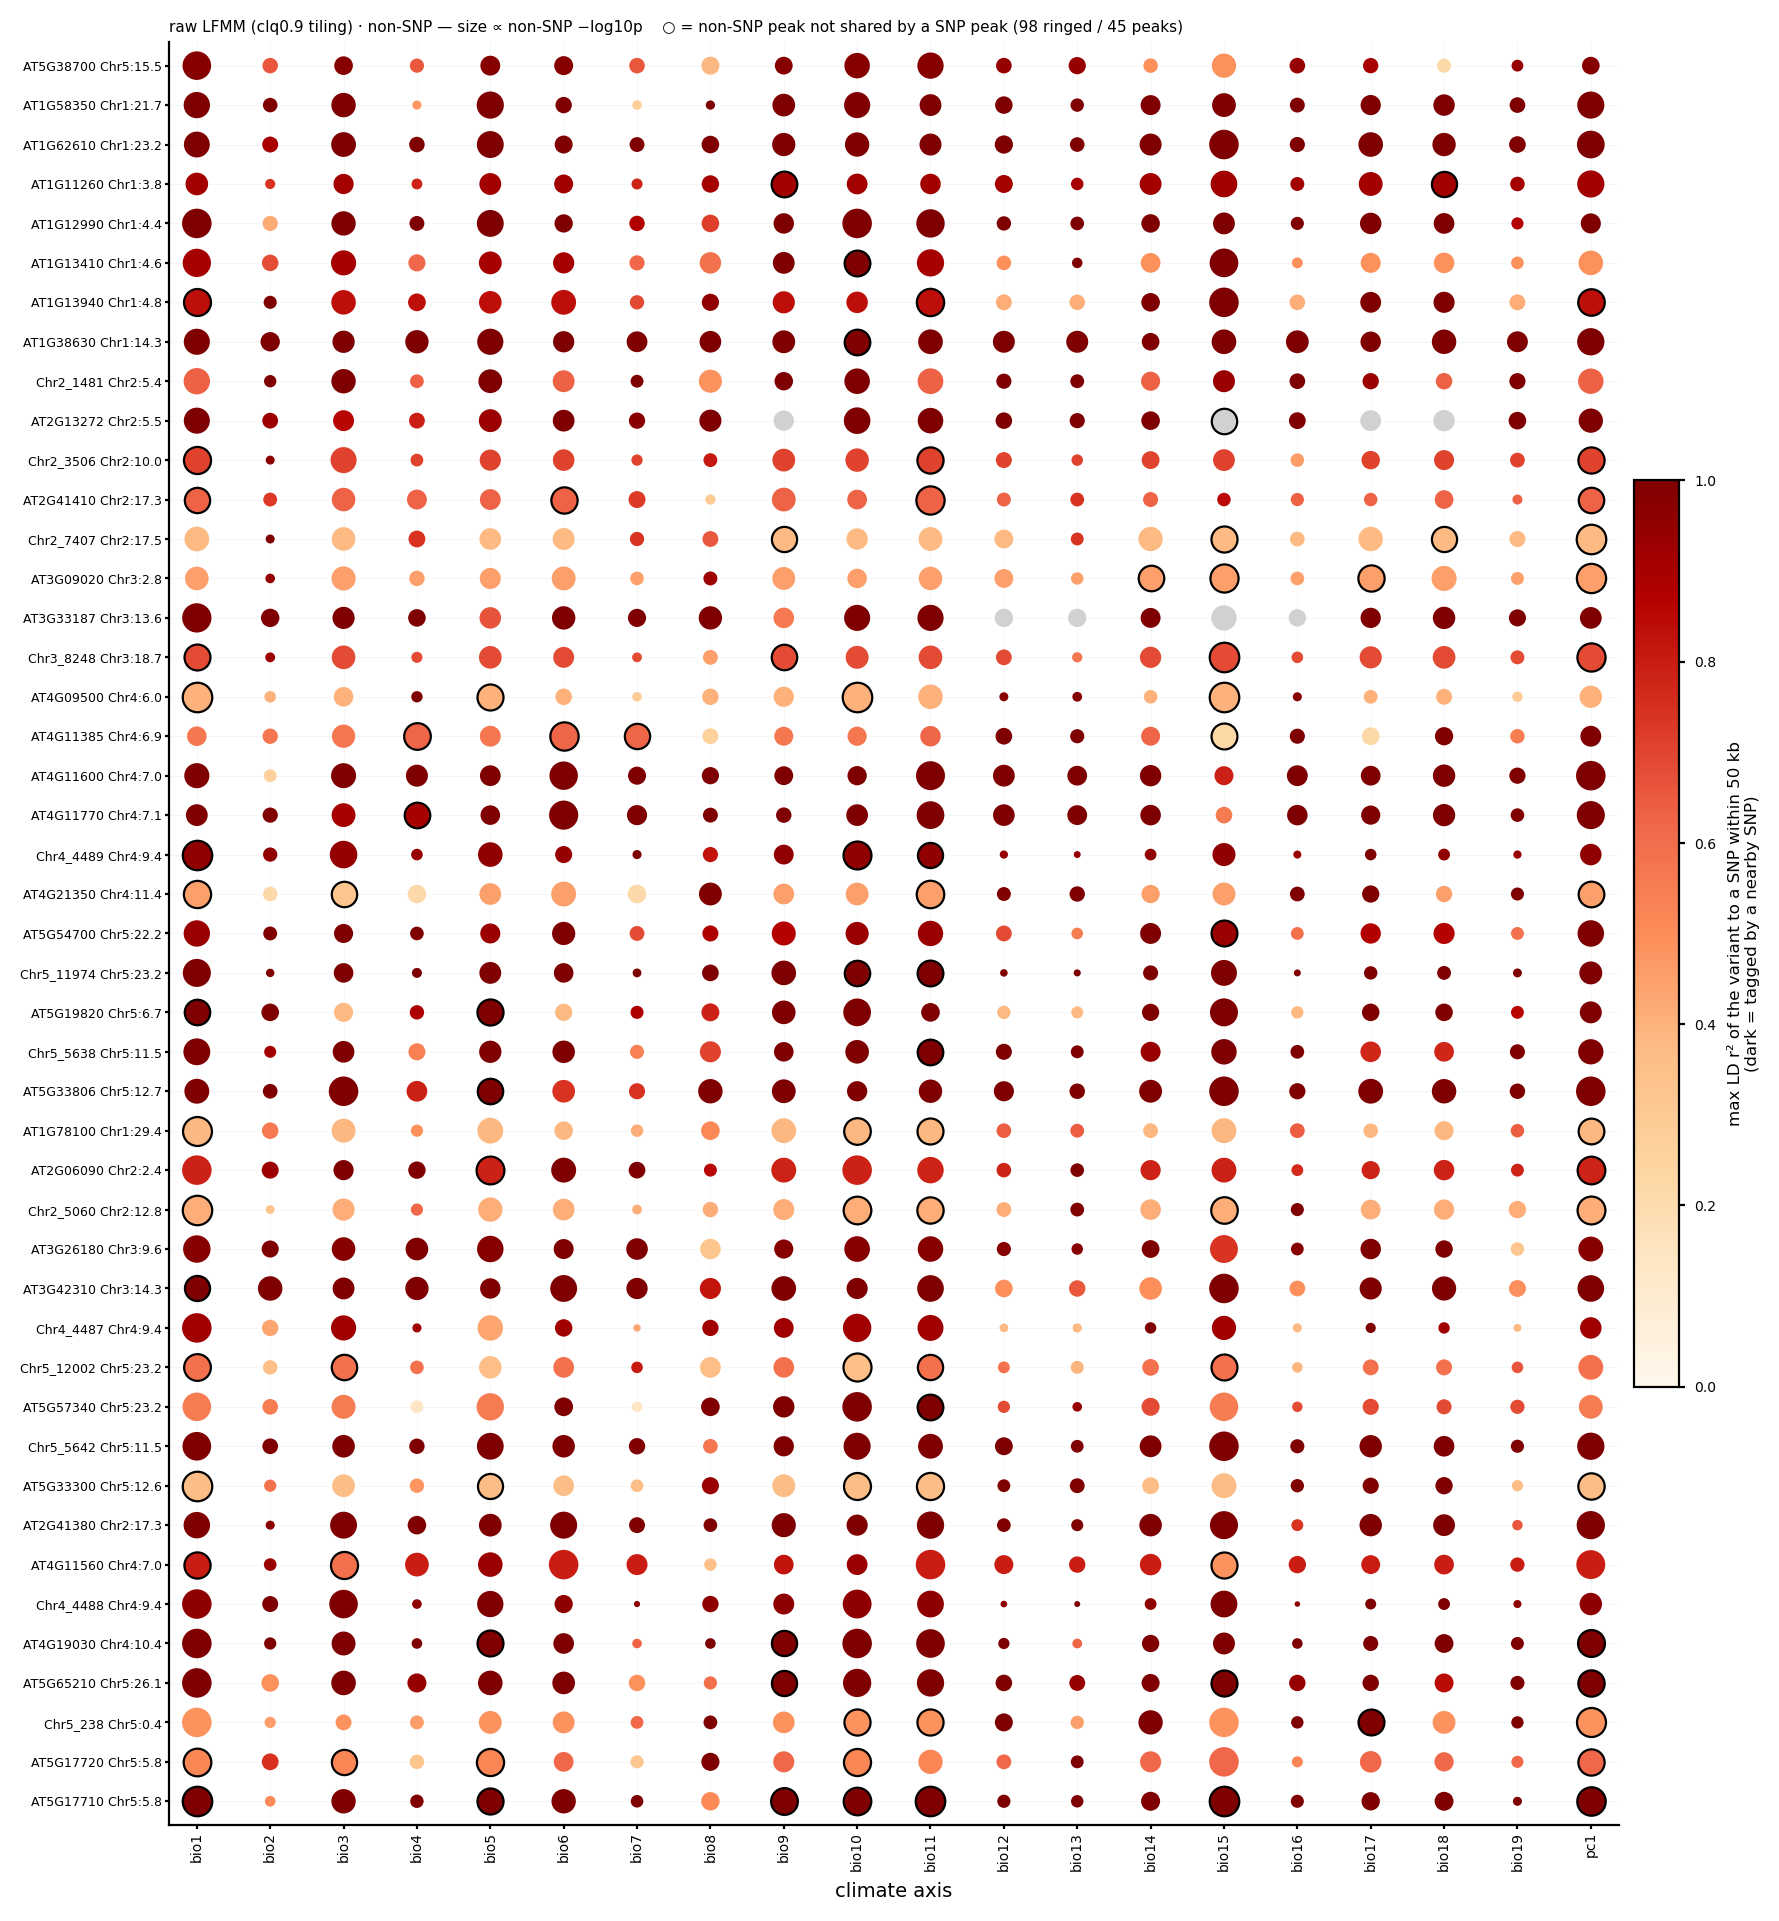

45 peaks: 98 ringed cells; 8 grey (untestable)


In [4]:
draw(peaks[:45], pitch=0.20, dot_base=3, dot_scale=11, yfont=4.5, ringlw=0.8)

### All non-SNP peaks (dense — full set)

dense view: showing 150 of 984 non-SNP peaks (full set in CSV)


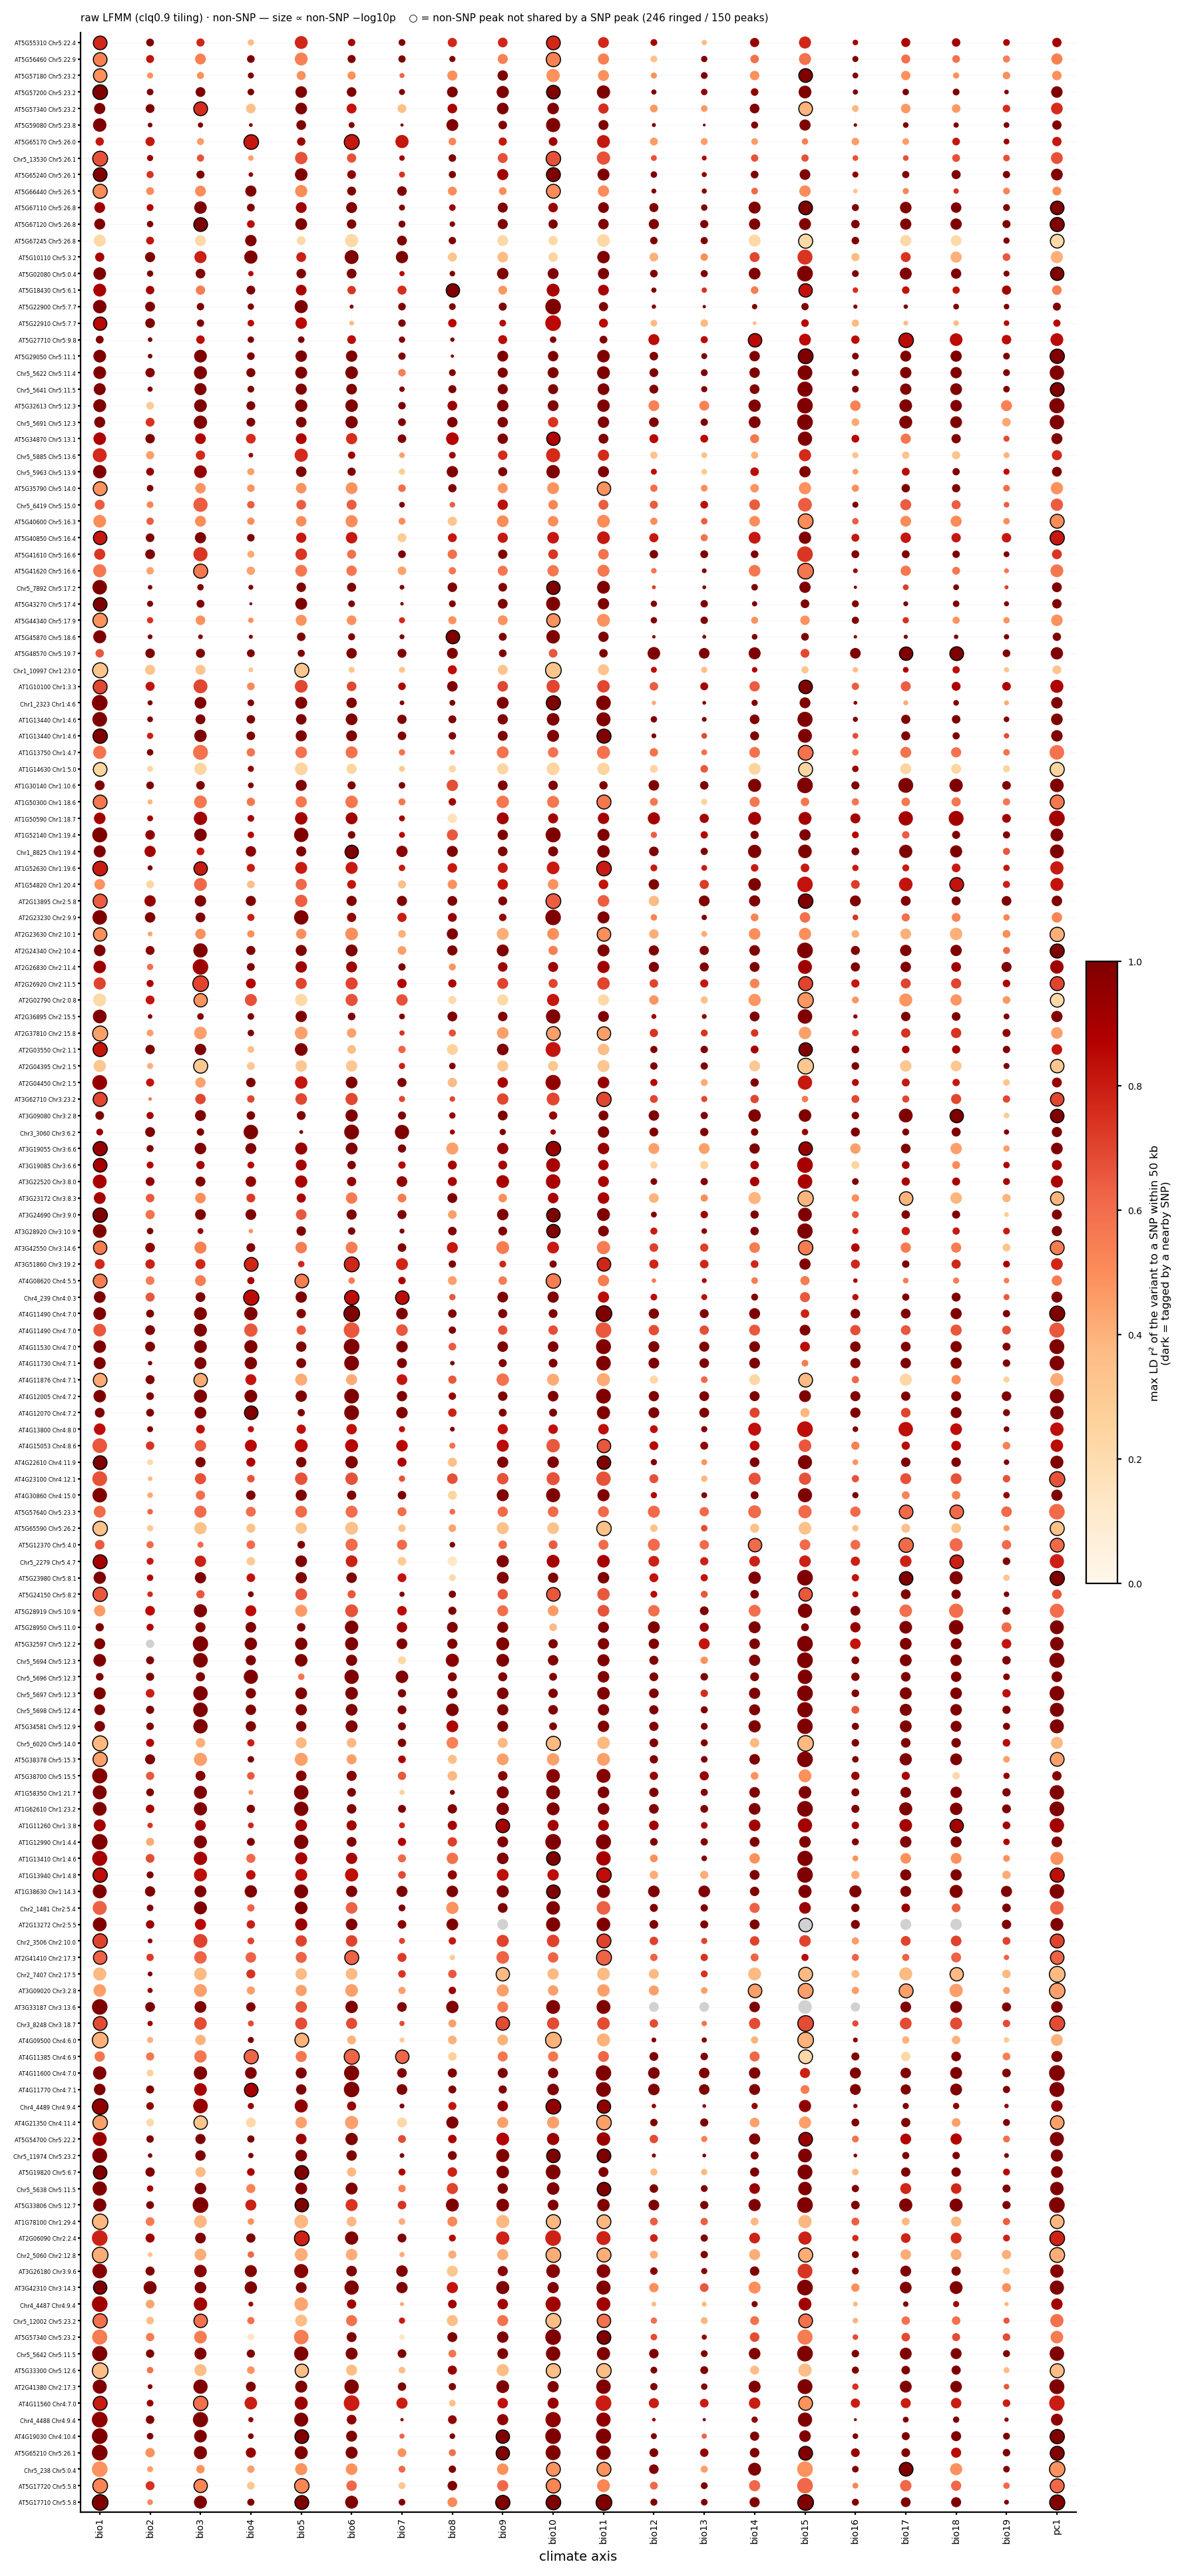

150 peaks: 246 ringed cells; 9 grey (untestable)


In [5]:
DENSE_N = min(150, len(peaks))
print(f"dense view: showing {DENSE_N} of {len(peaks)} non-SNP peaks (full set in CSV)")
draw(peaks[:DENSE_N], pitch=0.125, dot_base=2, dot_scale=7, yfont=3.0, ringlw=0.55)

In [6]:
rows = []
for (b, axis), (nlp, ns_sig, snp_sig, r2) in grid.items():
    if b not in peaks: continue
    gs = genes_on(b)
    rows.append(dict(block=b, axis=axis, gene=(gs[0] if gs else ""), nonsnp_nlp=round(nlp, 3),
                     nonsnp_bonf_sig=ns_sig, snp_bonf_sig=snp_sig, nonsnp_only=(ns_sig and not snp_sig),
                     lead_snp_r2=(round(r2, 4) if np.isfinite(r2) else np.nan)))
tab = pd.DataFrame(rows).sort_values(["block", "axis"])
tab.to_csv(f"{OUTDIR}/nonsnp_peak_dotgrid_lfmm_tile.csv", index=False)
print("wrote", f"{OUTDIR}/nonsnp_peak_dotgrid_lfmm_tile.csv", "|", len(peaks), "peaks x", len(AXES), "axes")

wrote /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/multiaxis/nonsnp_peak_dotgrid_lfmm_tile.csv | 984 peaks x 20 axes


## 3. Blocks marked by non-SNP/SV but never by SNP — candidate genes

Per-class significant blocks, **union over all 20 axes** (Bonferroni and FDR tiers
separately): a block counts as "non-SNP-only" if SV or smallindel calls it significant
in &ge;1 axis, but SNP **never** does, in any axis. Same clq0.9-tiling partition, raw
per-record p-values. Gene symbols/descriptions via Ensembl Plants REST (local TAIR10
GFF has AT-IDs only); functional-category tags use the same heat/drought-ABA/cold/
flowering-circadian keyword scheme as `candidate_genes_corrected.py` (built for the
strict partition — different block boundaries, so gene sets differ).

In [7]:

import json, time, urllib.request

def sig_blocks_by_class_axis(cls, axis):
    """One CSV read -> (bonf_set, fdr_set) for this (class, axis), cached by caller."""
    d = pd.read_csv(f"{IND}/lfmm_{cls}_gen9_{axis}.csv", usecols=["block", "MAF", "pval"])
    d = d[d.MAF > 0.05].copy()
    n = len(d)
    bonf = set(d.loc[d.pval < 0.05 / n, "block"])
    q = bh(d.pval.to_numpy())
    fdr = set(d.loc[q < 0.05, "block"])
    return bonf, fdr

# compute every (class, axis) block-set ONCE (one CSV read each), reuse for both the
# union (per class) and the per-block axis-recurrence lookup below
sig_by_cls_axis = {}   # (cls, axis, tier) -> set(block)
for cls in ["snp", "sv", "smallindel"]:
    for axis in AXES:
        bonf, fdr = sig_blocks_by_class_axis(cls, axis)
        sig_by_cls_axis[(cls, axis, "bonf")] = bonf
        sig_by_cls_axis[(cls, axis, "fdr")] = fdr

sig_union = {}
for cls in ["snp", "sv", "smallindel"]:
    for tier in ["bonf", "fdr"]:
        sig_union[(cls, tier)] = set().union(*[sig_by_cls_axis[(cls, ax, tier)] for ax in AXES])

def axes_hit(b, classes, tier):
    return sorted(ax for ax in AXES for cls in classes if b in sig_by_cls_axis[(cls, ax, tier)])

ENSEMBL = "https://rest.ensembl.org/lookup/id"
def ensembl_symbols(ids, chunk=900, retries=3):
    out = {}
    for i in range(0, len(ids), chunk):
        sub = ids[i:i + chunk]
        req = urllib.request.Request(ENSEMBL, data=json.dumps({"ids": sub}).encode(),
                                     headers={"Content-Type": "application/json", "Accept": "application/json"})
        for attempt in range(retries):
            try:
                with urllib.request.urlopen(req, timeout=60) as r:
                    d = json.load(r)
                for k, v in d.items():
                    if v:
                        out[k] = (v.get("display_name", "") or "", (v.get("description", "") or "").split(" [Source")[0])
                break
            except Exception as e:
                print(f"  [ensembl] chunk {i} attempt {attempt+1}: {e}", flush=True); time.sleep(2)
    return out

CATS = {
    "heat":        r"heat|thermo|high temperature|chaperone|heat shock|hsp|hsf|dnaj",
    "drought_ABA": r"drought|abscisic|\baba\b|dehydrat|desicc|osmotic|water stress|stomat|dehydrin|late embryogenesis|proline|salt",
    "cold":        r"\bcold\b|freezing|chilling|\bcbf\b|frost|cor15",
    "flower_circ": r"flower|floral|photoperiod|vernaliz|infloresc|florigen|circadian|clock|rhythm|oscillat",
}
CURATED = {
    "HSFA2": "heat", "HSBP": "heat", "HSP17.4": "heat", "MBF1C": "heat",
    "RAS1": "drought_ABA", "DREB2A": "drought_ABA", "RD29A": "drought_ABA", "NCED3": "drought_ABA",
    "COR15A": "cold", "VRN2": "flower_circ", "FT": "flower_circ", "FLC": "flower_circ",
    "GI": "flower_circ", "CCA1": "flower_circ", "TOC1": "flower_circ", "PIF4": "flower_circ",
}

gene_tables = {}
for tier in ["bonf", "fdr"]:
    snp_set = sig_union[("snp", tier)]
    only = (sig_union[("sv", tier)] | sig_union[("smallindel", tier)]) - snp_set
    print(f"{tier}: SV-or-smallindel-sig blocks never hit by SNP (any axis) = {len(only)}")
    rows = []
    for b in sorted(only):
        gs = genes_on(b)
        if not gs: continue
        classes = sorted({cls for cls in ["sv", "smallindel"] if b in sig_union[(cls, tier)]})
        n_ax = len(axes_hit(b, classes, tier))
        for g in gs:
            rows.append(dict(block=b, gene=g, classes=";".join(classes), n_axes=n_ax))
    GH = pd.DataFrame(rows)
    if len(GH):
        sym = ensembl_symbols(sorted(GH.gene.unique()))
        GH["symbol"] = GH.gene.map(lambda x: sym.get(x, ("", ""))[0])
        GH["description"] = GH.gene.map(lambda x: sym.get(x, ("", ""))[1])
        txt = (GH.symbol.fillna("") + " " + GH.description.fillna("")).str.lower()
        GH["category"] = ""
        for cat, pat in CATS.items():
            GH.loc[(GH.category == "") & txt.str.contains(pat, regex=True, na=False), "category"] = cat
        for symn, cat in CURATED.items():
            GH.loc[GH.symbol == symn, "category"] = cat
    gene_tables[tier] = GH
    GH.to_csv(f"{OUTDIR}/nonsnp_only_blocks_genes_{tier}.csv", index=False)
    print(f"  -> {GH.block.nunique() if len(GH) else 0} blocks with a gene, "
          f"{GH.gene.nunique() if len(GH) else 0} unique genes -> {OUTDIR}/nonsnp_only_blocks_genes_{tier}.csv")


bonf: SV-or-smallindel-sig blocks never hit by SNP (any axis) = 725


  -> 564 blocks with a gene, 1169 unique genes -> /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/multiaxis/nonsnp_only_blocks_genes_bonf.csv
fdr: SV-or-smallindel-sig blocks never hit by SNP (any axis) = 3514


  -> 2321 blocks with a gene, 2638 unique genes -> /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/multiaxis/nonsnp_only_blocks_genes_fdr.csv


### Category-tagged candidates (Bonferroni tier)

In [8]:

GH = gene_tables["bonf"]
sub = GH[GH.category.fillna("") != ""].drop_duplicates("gene").sort_values(["category", "n_axes"], ascending=[True, False])
print(f"{len(sub)} category-tagged genes / {GH.gene.nunique()} total")
sub[["category", "block", "gene", "symbol", "description", "classes", "n_axes"]]


17 category-tagged genes / 1169 total


,category,block,gene,symbol,description,classes,n_axes
386,drought_ABA,Chr2_7314,AT2G41420,WIH2,proline-rich family protein,smallindel,4
536,drought_ABA,Chr3_5285,AT3G26910,AT3G26910,hydroxyproline-rich glycoprotein family protein,smallindel,1
1040,drought_ABA,Chr5_3307,AT5G19800,AT5G19800,hydroxyproline-rich glycoprotein family protein,sv,1
1041,drought_ABA,Chr5_3307,AT5G19810,AT5G19810,Proline-rich extensin-like family protein,sv,1
793,flower_circ,Chr4_7541,AT4G30200,VEL1,vernalization5/VIN3-like protein,smallindel,1
985,flower_circ,Chr5_1614,AT5G09805,IDL3,inflorescence deficient in abscission (IDA)-li...,smallindel,1
1017,heat,Chr5_2856,AT5G17710,EMB1241,Co-chaperone GrpE family protein,smallindel,7
682,heat,Chr4_2251,AT4G10130,AT4G10130,DNAJ heat shock N-terminal domain-containing p...,smallindel;sv,3
1107,heat,Chr5_5997,AT5G35753,AT5G35753,DnaJ heat shock amino-terminal domain protein ...,smallindel;sv,2
261,heat,Chr2_1037,AT2G05250,AT2G05250,DNAJ heat shock N-terminal domain-containing p...,smallindel,1


### Category-tagged candidates (FDR tier)

In [9]:

GH = gene_tables["fdr"]
sub = GH[GH.category.fillna("") != ""].drop_duplicates("gene").sort_values(["category", "n_axes"], ascending=[True, False])
print(f"{len(sub)} category-tagged genes / {GH.gene.nunique()} total")
sub[["category", "block", "gene", "symbol", "description", "classes", "n_axes"]]


61 category-tagged genes / 2638 total


,category,block,gene,symbol,description,classes,n_axes
2162,cold,Chr4_8693,AT4G37220,AT4G37220,Cold acclimation protein WCOR413 family,smallindel,3
239,cold,Chr1_1449,AT1G09070,SRC2,soybean regulated by cold-2,smallindel,1
539,cold,Chr1_5511,AT1G29390,COR314-TM2,cold regulated 314 thylakoid membrane 2,smallindel,1
540,cold,Chr1_5513,AT1G29395,COR413IM1,COLD REGULATED 314 INNER MEMBRANE 1,smallindel,1
270,drought_ABA,Chr1_14984,AT1G76180,ERD14,Dehydrin family protein,smallindel,6
...,...,...,...,...,...,...,...
1600,heat,Chr3_8608,AT3G51910,HSFA7A,heat shock transcription factor A7A,smallindel,1
1796,heat,Chr4_3148,AT4G12770,AT4G12770,Chaperone DnaJ-domain superfamily protein,smallindel,1
2531,heat,Chr5_2901,AT5G17840,AT5G17840,DnaJ/Hsp40 cysteine-rich domain superfamily pr...,smallindel,1
2551,heat,Chr5_3248,AT5G19540,AT5G19540,thermosome subunit gamma,smallindel,1


### Category counts, both tiers

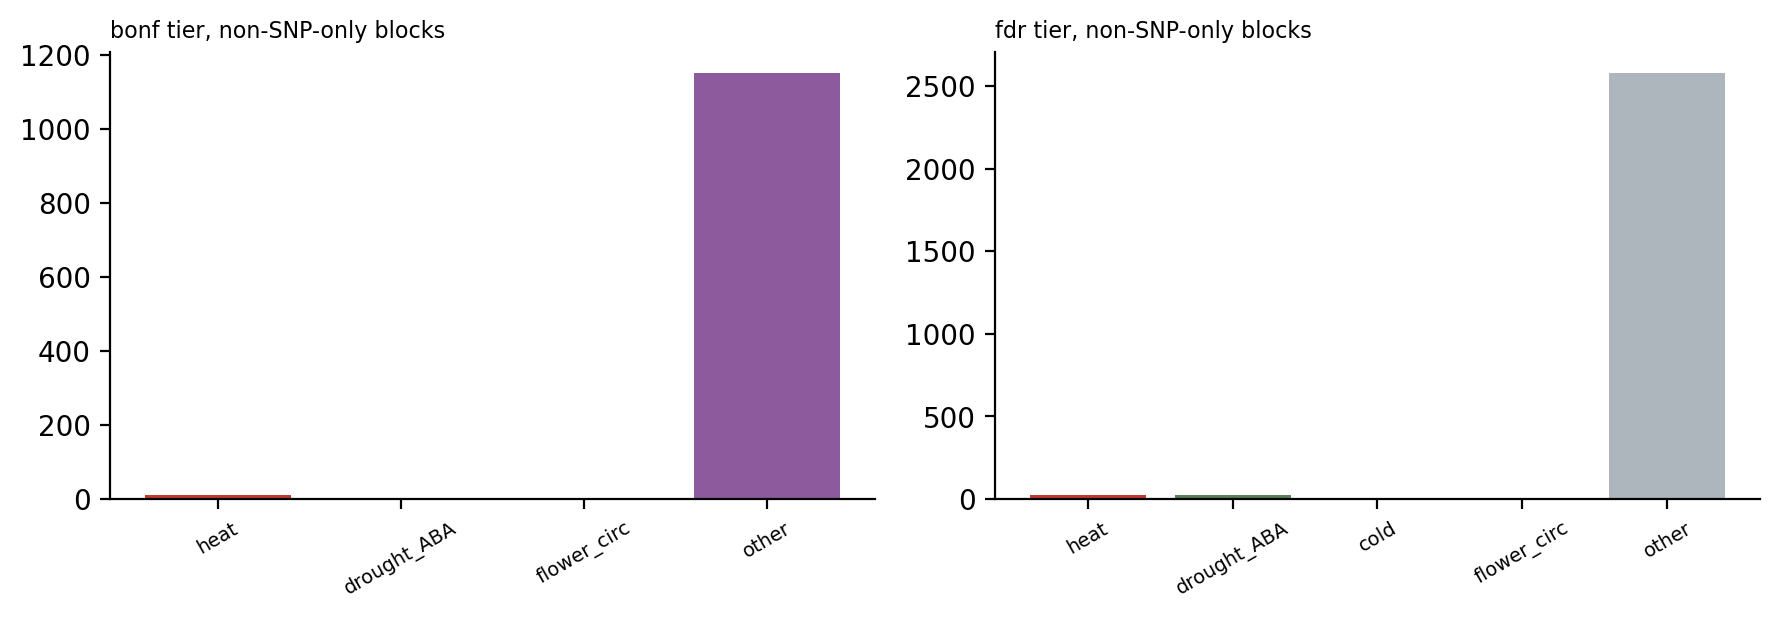

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, tier in zip(axes, ["bonf", "fdr"]):
    GH = gene_tables[tier].drop_duplicates("gene")
    counts = GH["category"].fillna("").replace("", "other").value_counts()
    counts = counts.reindex([c for c in ["heat", "drought_ABA", "cold", "flower_circ", "other"] if c in counts.index])
    ax.bar(counts.index, counts.values, color=["#C0392B", "#588157", "#3A5A98", "#8E5A9E", "#ADB5BD"][:len(counts)])
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
    ax.annotate(f"{tier} tier, non-SNP-only blocks", (0.0, 1.02), xycoords="axes fraction", fontsize=8, va="bottom")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()


## Takeaway

On the **clq0.9-tiling** partition (no records dropped to inter-block gaps), raw
per-record LFMM before any WZA aggregation shows a real class-specific signal: SV and
especially **smallindel** variants mark hundreds of blocks that SNPs never flag at
Bonferroni, and thousands at FDR, across the 20 climate axes. The non-SNP-only gene
set recurs in coherent functional families rather than scattering randomly — multiple
**heat-shock transcription factors** (HSFA1E/A3/A6A/A7A/A8/C1), **PFT1** (phytochrome/
flowering-time regulator, hit on 10/20 axes — the single most recurrent non-SNP-only
gene), the dehydrin **ERD14**, and several **COR** cold-regulated genes. Almost all of
this is driven by **smallindel**, not SV. Caveats: raw p is uncalibrated (no GIF); "not
marked by SNP" only means no significant SNP record fell in the *same tiling block* —
a coarser or finer partition could reassign genes between blocks; and this list hasn't
been cross-checked against the strict-partition candidate list in
`candidate_genes_corrected.csv` (different block boundaries).